## 1. Tải bộ dữ liệu "Millions of Movies" từ Kaggle bằng kagglehub và đọc file CSV vào DataFrame bằng pandas

In [9]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import kagglehub
akshaypawar7_millions_of_movies_path = kagglehub.dataset_download('akshaypawar7/millions-of-movies')
print('Data source import complete.')

Data source import complete.


In [11]:
import pandas as pd
df = pd.read_csv(akshaypawar7_millions_of_movies_path + "/movies.csv")
df.head()

,id,title,genres,original_language,overview,popularity,production_companies,release_date,budget,revenue,runtime,status,tagline,vote_average,vote_count,credits,keywords,poster_path,backdrop_path,recommendations
0,615656,Meg 2: The Trench,Action-Science Fiction-Horror,en,An exploratory dive into the deepest depths of...,8763.998,Apelles Entertainment-Warner Bros. Pictures-di...,2023-08-02,129000000.0,3.520565e+08,116.0,Released,Back for seconds.,7.079,1365.0,Jason Statham-Wu Jing-Shuya Sophia Cai-Sergio ...,based on novel or book-sequel-kaiju,/4m1Au3YkjqsxF8iwQy0fPYSxE0h.jpg,/qlxy8yo5bcgUw2KAmmojUKp4rHd.jpg,1006462-298618-569094-1061181-346698-1076487-6...
1,758323,The Pope's Exorcist,Horror-Mystery-Thriller,en,Father Gabriele Amorth Chief Exorcist of the V...,5953.227,Screen Gems-2.0 Entertainment-Jesus & Mary-Wor...,2023-04-05,18000000.0,6.567582e+07,103.0,Released,Inspired by the actual files of Father Gabriel...,7.433,545.0,Russell Crowe-Daniel Zovatto-Alex Essoe-Franco...,spain-rome italy-vatican-pope-pig-possession-c...,/9JBEPLTPSm0d1mbEcLxULjJq9Eh.jpg,/hiHGRbyTcbZoLsYYkO4QiCLYe34.jpg,713704-296271-502356-1076605-1084225-1008005-9...
2,533535,Deadpool & Wolverine,Action-Comedy-Science Fiction,en,A listless Wade Wilson toils away in civilian ...,5410.496,Marvel Studios-Maximum Effort-21 Laps Entertai...,2024-07-24,200000000.0,1.326387e+09,128.0,Released,Come together.,7.765,3749.0,Ryan Reynolds-Hugh Jackman-Emma Corrin-Matthew...,hero-superhero-anti hero-mutant-breaking the f...,/8cdWjvZQUExUUTzyp4t6EDMubfO.jpg,/dvBCdCohwWbsP5qAaglOXagDMtk.jpg,573435-519182-957452-1022789-945961-718821-103...
3,667538,Transformers: Rise of the Beasts,Action-Adventure-Science Fiction,en,When a new threat capable of destroying the en...,5409.104,Skydance-Paramount-di Bonaventura Pictures-Bay...,2023-06-06,200000000.0,4.070455e+08,127.0,Released,Unite or fall.,7.340,1007.0,Anthony Ramos-Dominique Fishback-Luna Lauren V...,peru-alien-end of the world-based on cartoon-b...,/gPbM0MK8CP8A174rmUwGsADNYKD.jpg,/woJbg7ZqidhpvqFGGMRhWQNoxwa.jpg,496450-569094-298618-385687-877100-598331-4628...
4,693134,Dune: Part Two,Science Fiction-Adventure,en,Follow the mythic journey of Paul Atreides as ...,4742.163,Legendary Pictures,2024-02-27,190000000.0,6.838137e+08,167.0,Released,Long live the fighters.,8.300,2770.0,Timothée Chalamet-Zendaya-Rebecca Ferguson-Jav...,epic-based on novel or book-fight-sandstorm-sa...,/czembW0Rk1Ke7lCJGahbOhdCuhV.jpg,/xOMo8BRK7PfcJv9JCnx7s5hj0PX.jpg,438631-763215-792307-1011985-467244-634492-359...


## 2. Cài đặt các thư viện cần thiết

Bước này nhằm cài đặt và nhập các thư viện cần thiết cho đồ án.

In [12]:
# Cài đặt thư viện
!pip install kagglehub catboost xgboost lightgbm shap seaborn


[notice] A new release of pip is available: 23.2.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
# Nhập thư viện
# Thư viện xử lý dữ liệu
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Thư viện trực quan hóa
import matplotlib.pyplot as plt
import seaborn as sns

# Thư viện mô hình học máy
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor
from catboost import CatBoostRegressor
import xgboost as xgb
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import shap

%matplotlib inline

## 3. Tìm hiểu về bộ dữ liệu

Bước này giúp hiểu rõ cấu trúc và đặc điểm của dữ liệu trước khi tiền xử lý. df.info() và df.shape cung cấp thông tin về số dòng, số cột, kiểu dữ liệu, và giá trị thiếu. df.describe() cho biết phân bố dữ liệu (trung bình, độ lệch chuẩn, giá trị min/max, quartiles), giúp phát hiện các vấn đề như giá trị 0 trong budget, revenue, runtime. Heatmap (sns.heatmap) trực quan hóa giá trị thiếu, và hàm nans() liệt kê các dòng có giá trị thiếu. Bước này quan trọng vì nó giúp xác định các vấn đề cần xử lý (giá trị thiếu, giá trị 0, ngoại lai) để chuẩn bị dữ liệu sạch cho dự đoán revenue và popularity.

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 722317 entries, 0 to 722316
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    722317 non-null  int64  
 1   title                 722311 non-null  object 
 2   genres                512000 non-null  object 
 3   original_language     722317 non-null  object 
 4   overview              604074 non-null  object 
 5   popularity            722317 non-null  float64
 6   production_companies  337391 non-null  object 
 7   release_date          670768 non-null  object 
 8   budget                722317 non-null  float64
 9   revenue               722317 non-null  float64
 10  runtime               687982 non-null  float64
 11  status                722317 non-null  object 
 12  tagline               108476 non-null  object 
 13  vote_average          722317 non-null  float64
 14  vote_count            722317 non-null  float64
 15  

In [15]:
df.shape

(722317, 20)

In [16]:
df.describe()

,id,popularity,budget,revenue,runtime,vote_average,vote_count
count,722317.000000,722317.000000,7.223170e+05,7.223170e+05,6.879820e+05,722317.000000,722317.000000
mean,526920.121246,1.918179,4.043453e+05,1.007747e+06,1.990905e+02,2.446389,28.484715
std,253200.153542,23.692240,8.242868e+06,2.048321e+07,8.584257e+04,3.176491,396.575042
min,2.000000,0.000000,0.000000e+00,-1.200000e+01,0.000000e+00,0.000000,0.000000
25%,328914.000000,0.600000,0.000000e+00,0.000000e+00,5.000000e+00,0.000000,0.000000
50%,533351.000000,0.600000,0.000000e+00,0.000000e+00,5.000000e+01,0.000000,0.000000
75%,737872.000000,1.303000,0.000000e+00,0.000000e+00,9.000000e+01,5.600000,2.000000
max,968161.000000,8763.998000,5.000000e+09,2.920357e+09,5.050505e+07,10.000000,34857.000000


<Axes: >

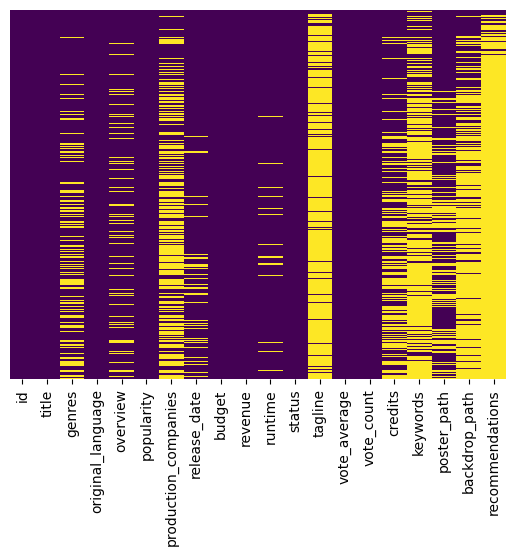

In [17]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [18]:
def nans(df): return df[df.isnull().any(axis=1)]
nans(df)

,id,title,genres,original_language,overview,popularity,production_companies,release_date,budget,revenue,runtime,status,tagline,vote_average,vote_count,credits,keywords,poster_path,backdrop_path,recommendations
13,956101,The Eighth Clause,Thriller,la,Kat and Borja appear to be a perfect couple bu...,2259.303,SDB Films-El Hombre Orquesta,2022-04-29,0.0,0.0,0.0,Released,NaN,4.600,10.0,Maite Perroni-Manuel Vega-Óscar Jaenada-Jessic...,NaN,/8tc8eMFAX2SDC1TRu987qFQy8Cl.jpg,/kLnqNE9Af5QHyvUxw8cDGhF1ilv.jpg,NaN
14,572802,Aquaman and the Lost Kingdom,Action-Adventure-Fantasy,en,Black Manta still driven by the need to avenge...,2141.691,Warner Bros. Pictures-The Safran Company-Atomi...,2023-12-20,205000000.0,397860076.0,124.0,Released,The tide is turning.,6.786,756.0,Patrick Wilson-Yahya Abdul-Mateen II-Randall P...,superhero-secret society-half-brother-sequel-r...,/7lTnXOy0iNtBAdRP3TZvaKJ77F6.jpg,/jXJxMcVoEuXzym3vFnjqDW4ifo6.jpg,NaN
18,753342,Napoleon,History-War-Drama,en,An epic that details the checkered rise and fa...,1811.360,Scott Free Productions-Latina Pictures-Apple S...,2023-11-22,165000000.0,213400000.0,158.0,Released,He came from nothing. He conquered everything.,6.516,1282.0,Joaquin Phoenix-Vanessa Kirby-Rupert Everett-M...,empire-france-biography-napoleon bonaparte-bas...,/jE5o7y9K6pZtWNNMEw3IdpHuncR.jpg,/f1AQhx6ZfGhPZFTVKgxG91PhEYc.jpg,NaN
21,968051,The Nun II,Horror-Mystery-Thriller,en,In 1956 France a priest is violently murdered ...,1696.620,New Line Cinema-Atomic Monster-The Safran Company,2023-09-06,38500000.0,257010000.0,110.0,Released,Confess your sins.,7.004,1073.0,Taissa Farmiga-Jonas Bloquet-Storm Reid-Anna P...,france-bullying-sequel-religion-demon-gothic h...,/5gzzkR7y3hnY8AD1wXjCnVlHba5.jpg,/53z2fXEKfnNg2uSOPss2unPBGX1.jpg,NaN
22,965839,Lord of the Streets,Action,en,When Jason Dyson refuses to make his prized fi...,1691.825,Mutiny Films,2022-04-22,1000000.0,0.0,85.0,Released,NaN,4.900,29.0,Treach-Quinton Jackson-Khalil Rountree Jr.-And...,NaN,/n9YWVQRc0zw0nwrFcOkOpffZxjc.jpg,/g8Yytnby0hIPft5l56mgJtZyR1k.jpg,982467
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
722312,836042,Tomcat Tales,Documentary-History-War,en,Learn from real-life Top Guns who have flown a...,0.001,NaN,2020-01-01,0.0,0.0,120.0,Released,NaN,0.000,0.0,NaN,NaN,/8mkAUkkRCLvMBMBvLFvhLF9SPC4.jpg,NaN,NaN
722313,527223,Strictly Modern,Comedy-Romance,en,Strictly Modern is a 1930 American pre-Code co...,0.001,First National Pictures-Warner Bros. Entertain...,1930-03-02,0.0,0.0,63.0,Released,Dorothy MACKAILL -THE WOMAN who thought she kn...,0.000,0.0,Dorothy Mackaill-Sidney Blackmer-Julanne Johns...,lost film,/qr4dU5DOhOJ3YTBdpdXpG6AUOyZ.jpg,NaN,NaN
722314,717787,Your Letter,Animation-Drama-Mystery-Adventure,ko,Sori Lee is hoping for a fresh start at her ne...,0.001,Studio N,2024-09-27,0.0,0.0,97.0,Released,NaN,0.000,0.0,Lee Soo-hyun-Kim Min-ju-Min Seungwoo-Nam Doh-h...,bullying-slice of life-school life,NaN,/thsAU92Ei2Nbm38ZdkvHI8xLaSc.jpg,NaN
722315,718477,Café Tacvba - Un Viaje,NaN,en,Un Viaje is the first live album by the rock b...,0.001,NaN,2005-04-19,0.0,0.0,120.0,Released,NaN,0.000,0.0,Rubén Albarrán-Emmanuel del Real-Joselo Rangel...,NaN,/95HgsWBDuSJBgcq0Fkv4JYZeTdR.jpg,/laiCThOhK5LKJJsMSXSzoePv8uX.jpg,NaN


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 722317 entries, 0 to 722316
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    722317 non-null  int64  
 1   title                 722311 non-null  object 
 2   genres                512000 non-null  object 
 3   original_language     722317 non-null  object 
 4   overview              604074 non-null  object 
 5   popularity            722317 non-null  float64
 6   production_companies  337391 non-null  object 
 7   release_date          670768 non-null  object 
 8   budget                722317 non-null  float64
 9   revenue               722317 non-null  float64
 10  runtime               687982 non-null  float64
 11  status                722317 non-null  object 
 12  tagline               108476 non-null  object 
 13  vote_average          722317 non-null  float64
 14  vote_count            722317 non-null  float64
 15  

In [20]:
print ('The data has {} rows and {} columns'.format(df.shape[0],df.shape[1]))

The data has 722317 rows and 20 columns


## 4. Loại bỏ dữ liệu dư thừa và không phù hợp

Bước này nhằm loại bỏ các dữ liệu không phù hợp để đảm bảo chất lượng dữ liệu cho việc dự đoán:

In [21]:
# Loại bỏ dữ liệu dư thừa và không phù hợp
# Mục tiêu: Loại bỏ duplicates, phim chưa phát hành, phim thiếu release_date, phim có revenue bằng 0, và lọc phim từ năm 2000
# Loại bỏ duplicates dựa trên id
df = df.drop_duplicates(subset='id', keep='first')

# Loại bỏ phim chưa phát hành và cột status
df = df[df['status'] == 'Released']
df = df.drop('status', axis=1)

# Loại bỏ phim không có release_date
df = df.dropna(subset=['release_date'])

# Chuyển đổi release_date thành datetime và lọc phim từ năm 1900
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df = df[df['release_date'] >= '1900-01-01']

# Loại bỏ phim có revenue bằng 0
df = df[df['revenue'] > 0]

# Kiểm tra kích thước dữ liệu sau khi lọc
print("Kích thước dữ liệu sau khi loại bỏ dữ liệu không phù hợp:", df.shape)

Kích thước dữ liệu sau khi loại bỏ dữ liệu không phù hợp: (16033, 19)


Tiếp theo là tiến hành xử lý các giá trị 0, giá trị thiếu, ngoại lai, và chuẩn hóa để tiếp tục làm sạch dữ liệu chuẩn bị cho mô hình dự đoán:

In [22]:
# Loại bỏ phim có revenue hoặc popularity bằng 0
df = df[df['revenue'] > 0]
df = df[df['popularity'] > 0]
# Loại bỏ phim có budget hoặc runtime bằng 0
df = df[df['budget'] > 0]
df = df[df['runtime'] > 0]
print ('Hiện tại, bộ dữ liệu sau khi xử lý còn {} hàng và {} cột'.format(df.shape[0],df.shape[1]))

Hiện tại, bộ dữ liệu sau khi xử lý còn 10189 hàng và 19 cột


In [23]:
# Xử lý giá trị thiếu
df['vote_average'] = df['vote_average'].fillna(df['vote_average'].mean())
df['vote_count'] = df['vote_count'].fillna(df['vote_count'].median())
df['genres'] = df['genres'].fillna('Unknown')
df['production_companies'] = df['production_companies'].fillna('Unknown')

In [24]:
# Xử lý giá trị 0, giá trị thiếu, ngoại lai, và chuẩn hóa dữ liệu
# Mục tiêu: Làm sạch dữ liệu (loại bỏ giá trị 0, ngoại lai, xử lý giá trị thiếu), trích xuất đặc trưng, chuẩn hóa để sẵn sàng cho mô hình
# Loại bỏ phim có popularity, budget, runtime bằng 0
df = df[df['popularity'] > 0]
df = df[df['budget'] > 0]
df = df[df['runtime'] > 0]

# Xử lý giá trị thiếu
df['vote_average'] = df['vote_average'].fillna(df['vote_average'].mean())
df['vote_count'] = df['vote_count'].fillna(df['vote_count'].median())
df['genres'] = df['genres'].fillna('Unknown')
df['production_companies'] = df['production_companies'].fillna('Unknown')

# Xử lý giá trị ngoại lai bằng IQR
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df

for col in ['budget', 'revenue', 'popularity', 'runtime', 'vote_average', 'vote_count']:
    df = remove_outliers(df, col)

# Chuẩn hóa dữ liệu số
scaler = MinMaxScaler()
numeric_columns = ['budget', 'revenue', 'popularity', 'runtime', 'vote_average', 'vote_count']
df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

# Kiểm tra lại dữ liệu
print("Kích thước dữ liệu cuối cùng:", df.shape)
print("Giá trị thiếu cuối cùng:\n", df.isna().sum())
print("Dữ liệu sau tiền xử lý:\n", df.head())

Kích thước dữ liệu cuối cùng: (5895, 19)
Giá trị thiếu cuối cùng:
 id                         0
title                      0
genres                     0
original_language          0
overview                  14
popularity                 0
production_companies       0
release_date               0
budget                     0
revenue                    0
runtime                    0
tagline                 1355
vote_average               0
vote_count                 0
credits                   11
keywords                 653
poster_path               22
backdrop_path            267
recommendations         1772
dtype: int64
Dữ liệu sau tiền xử lý:
           id                               title  \
2624   21972                           Like Mike   
2627    1687  Escape from the Planet of the Apes   
2639  734002                        The Peasants   
2644   11212                      Baby's Day Out   
2652   59429    Paranormal Activity: Tokyo Night   

                               

In [25]:
# Xuất dữ liệu sau khi tiền xử lý ra file CSV
output_path = "processed_movies.csv"  
df.to_csv(output_path, index=False, encoding='utf-8')
print(f"Dữ liệu đã được xuất ra file: {output_path}")

Dữ liệu đã được xuất ra file: processed_movies.csv
